# Etapa 0

Carregamento de bibliotecas

In [1]:
import cv2
import matplotlib.pyplot as plt
import random
import numpy as np
from pathlib import Path

# Etapa 1

Foram coletadas 6 imagens em resolução 4032x3024. Para melhor performance, as imagens serão redimensionadas com o fator x0.25, utilizando Lanczos.

## Redimensionamento

In [2]:
from src.resize import resize_images

images_raw_dir = Path("./data/raw/")
images_processed_dir = Path("./data/processed")

resize_images(images_raw_dir, images_processed_dir, 0.25)

IMG_0301.JPG: 4032x3024 -> 1008x756
IMG_0302.JPG: 4032x3024 -> 1008x756
IMG_0303.JPG: 4032x3024 -> 1008x756
IMG_0304.JPG: 4032x3024 -> 1008x756
IMG_0305.JPG: 4032x3024 -> 1008x756
IMG_0306.JPG: 4032x3024 -> 1008x756
IMG_0307.JPG: 4032x3024 -> 1008x756


## Carregregamento das imagens

In [3]:
def plot_image_grid(images, title="Imagens", layout=(2, 3), size=(10, 6)):
    fig, axes = plt.subplots(layout[0], layout[1], figsize=size)
    fig.suptitle(title)
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        ax.axis('off')
        ax.set_title(f'Imagem {i}')

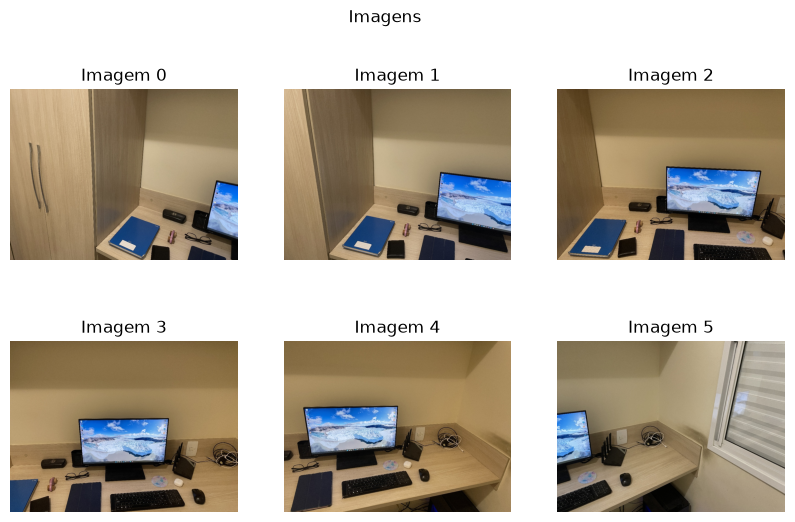

In [4]:
images = []
for image_path in sorted(images_processed_dir.iterdir()):
    image = cv2.imread(image_path)
    images.append(image)

# random.shuffle(images)
plot_image_grid(images)

Par 0 -> 1: OK (716, 1345, 3)


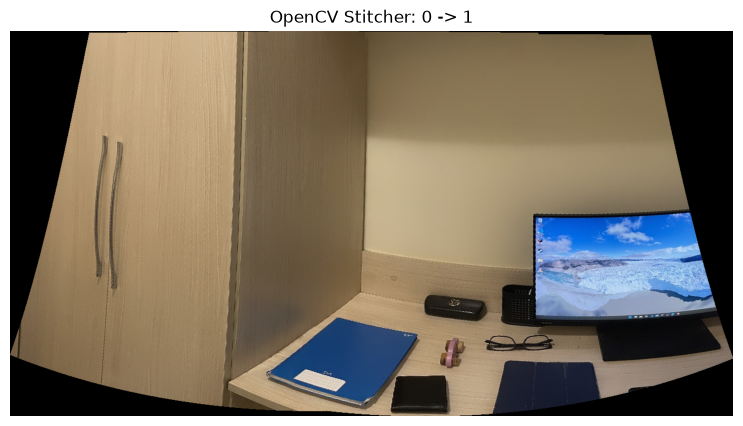

Par 1 -> 2: OK (724, 1311, 3)


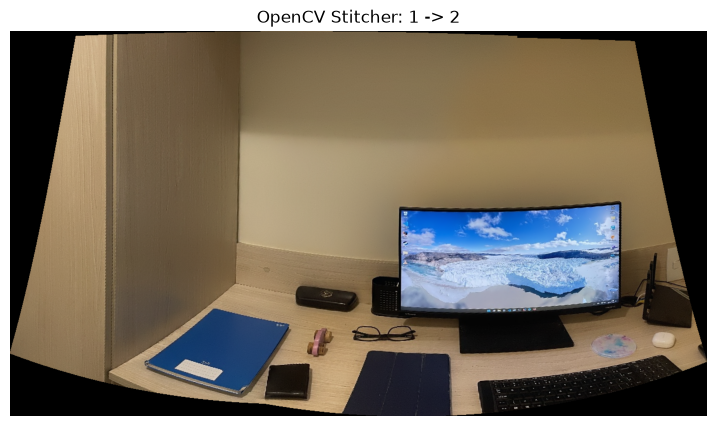

Par 2 -> 3: OK (707, 1210, 3)


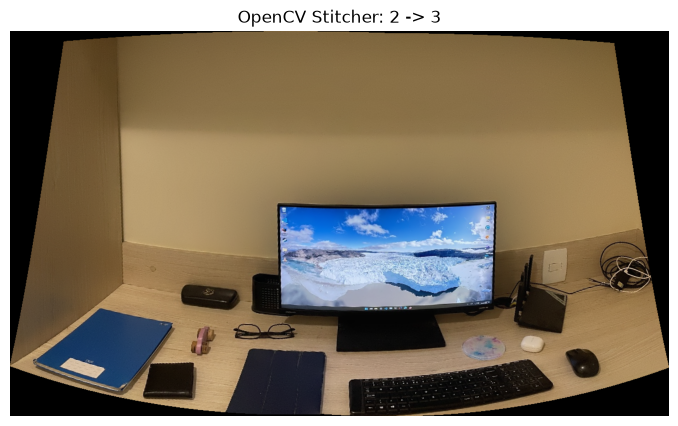

Par 3 -> 4: OK (759, 1124, 3)


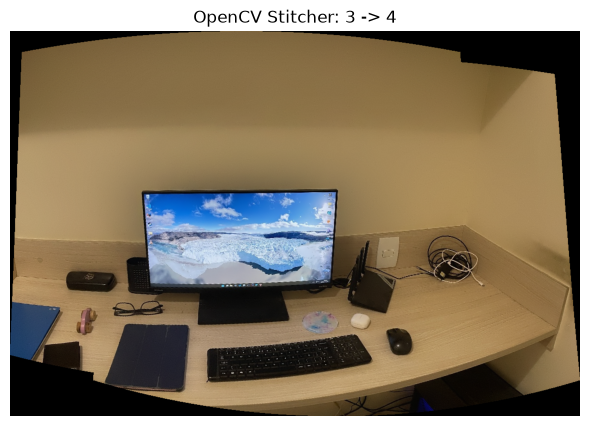

Par 4 -> 5: OK (780, 1603, 3)


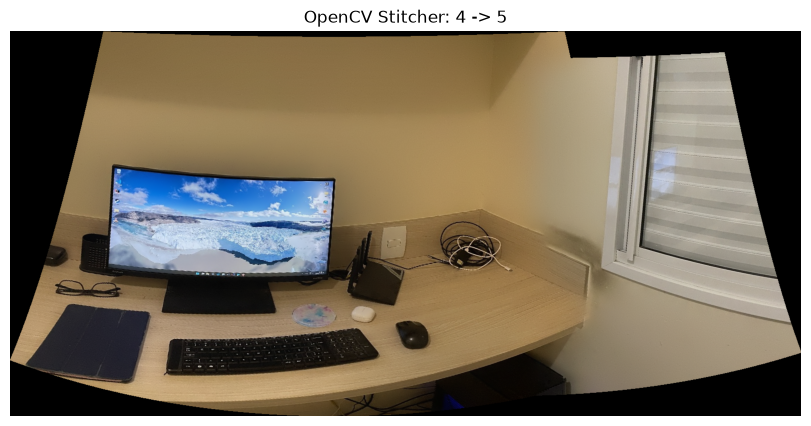

Par 5 -> 6: OK (749, 1260, 3)


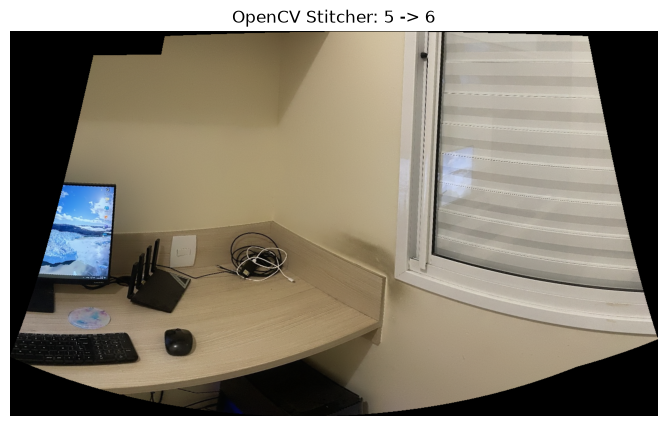

In [5]:
for i in range(len(images) - 1):

    pair = [
        images[i],
        images[i + 1]
    ]

    stitcher = cv2.Stitcher_create(
        cv2.Stitcher_PANORAMA
    )

    status, result = stitcher.stitch(pair)

    print(
        f"Par {i} -> {i+1}: ",
        end=""
    )

    if status == cv2.Stitcher_OK:
        print("OK", result.shape)

        plt.figure(figsize=(12, 5))
        plt.imshow(
            cv2.cvtColor(
                result,
                cv2.COLOR_BGR2RGB
            )
        )
        plt.title(f"OpenCV Stitcher: {i} -> {i+1}")
        plt.axis("off")
        plt.show()
        plt.close()

    else:
        print(f"FALHOU (status={status})")

OpenCV: 5.0.0


Status: 0
Panorama criado com sucesso!
Tamanho: (808, 2242, 3)


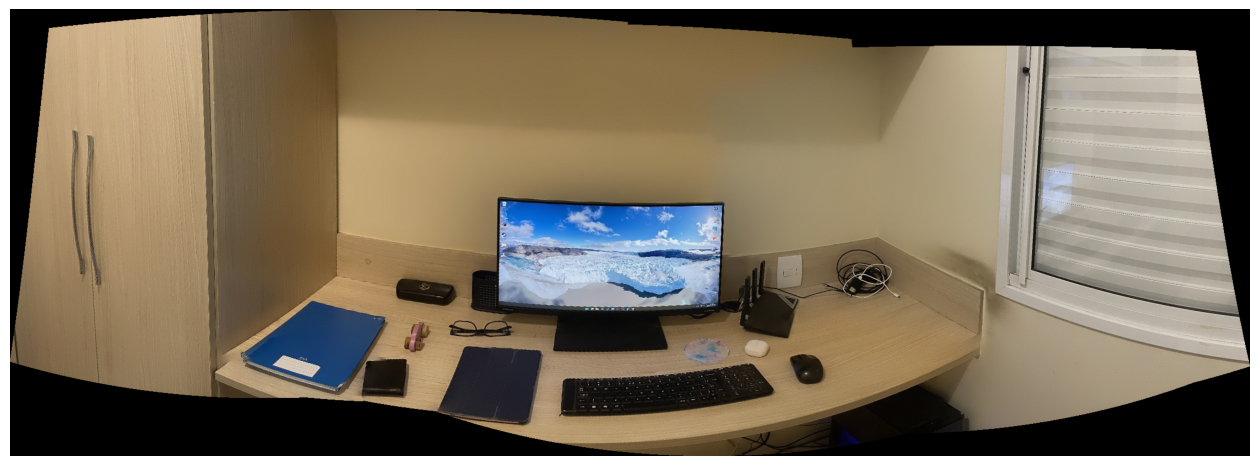

In [6]:
import cv2
import matplotlib.pyplot as plt

print("OpenCV:", cv2.__version__)

stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)

status, panorama = stitcher.stitch(images)

print("Status:", status)

if status == cv2.Stitcher_OK:
    print("Panorama criado com sucesso!")
    print("Tamanho:", panorama.shape)

    plt.figure(figsize=(16, 8))
    plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    cv2.imwrite(
        "results/panorama_opencv.jpg",
        panorama
    )

else:
    print("O Stitcher falhou.")
    
    if status == cv2.Stitcher_ERR_NEED_MORE_IMGS:
        print("Poucas correspondências/imagens suficientes.")
    elif status == cv2.Stitcher_ERR_HOMOGRAPHY_EST_FAIL:
        print("Falha na estimação da homografia.")
    elif status == cv2.Stitcher_ERR_CAMERA_PARAMS_ADJUST_FAIL:
        print("Falha no ajuste dos parâmetros da câmera.")
    else:
        print("Código de erro desconhecido.")

# Etapa 2

Detecção de keypoints com SIFT e ORB

Detector: sift
Número de keypoints: 476
Formato dos descritores: (476, 128)
Número de keypoints: 820
Formato dos descritores: (820, 128)
Número de keypoints: 899
Formato dos descritores: (899, 128)
Número de keypoints: 1004
Formato dos descritores: (1004, 128)
Número de keypoints: 1142
Formato dos descritores: (1142, 128)
Número de keypoints: 754
Formato dos descritores: (754, 128)
Número de keypoints: 535
Formato dos descritores: (535, 128)


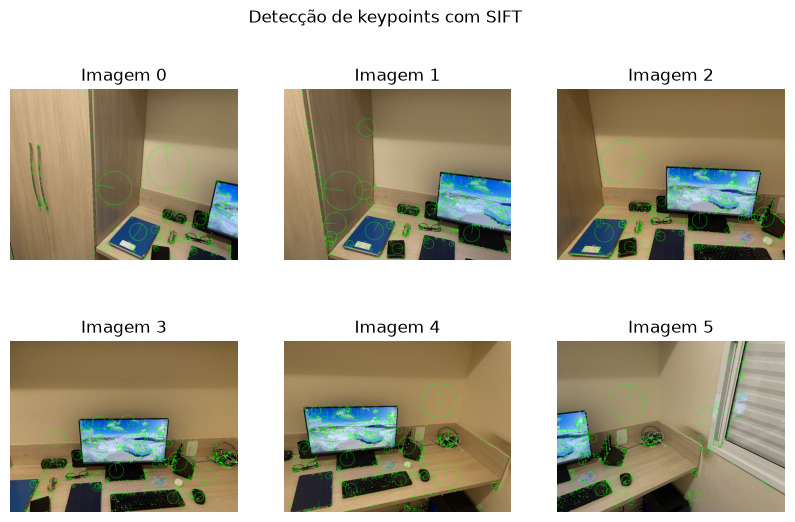

In [7]:
from src.features import draw_keypoints

images_sift = draw_keypoints(images, "sift") # array de dicts contendo { "image": (valor),  "keypoints": (valor), "descriptors": (valor) }
plot_image_grid([item["image"] for item in images_sift], "Detecção de keypoints com SIFT") # extrai "image" de cada item no array

Detector: orb
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)


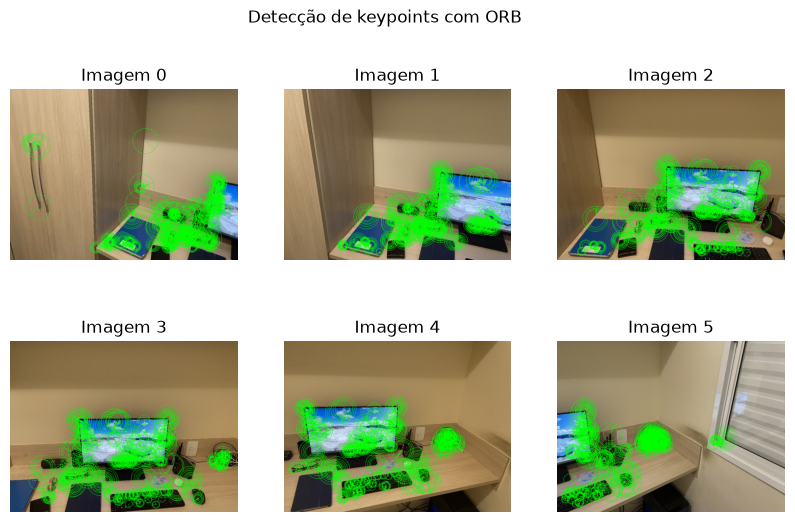

In [8]:
images_orb = draw_keypoints(images, "orb") # array de dicts contendo { "image": (valor),  "keypoints": (valor), "descriptors": (valor) }
plot_image_grid([item["image"] for item in images_orb], "Detecção de keypoints com ORB") # extrai "image" de cada item no array

# Etapa 3

In [9]:
from src.matching import match_all_images

RATIO_THRESHOLD = 0.75

# match_all_images retorna dois dicionários. A estrutura do dicionário é 
# { (i, j): matches } onde i e j são índices de imagem, e matches é uma lista de matches.
# i sempre é menor que j.
matches_dict, lowe_matches_dict = match_all_images(
    [item["descriptors"] for item in images_sift], # extrai "descriptors" de cada item no array
    method="sift",
    ratio=RATIO_THRESHOLD
)

print("Before Lowe")
for (i, j), matches in matches_dict.items():
    print(
        f"Imagem {i} <-> Imagem {j}: "
        f"{len(matches)} matches"
    )

print("After Lowe")
for (i, j), matches in lowe_matches_dict.items():
    print(
        f"Imagem {i} <-> Imagem {j}: "
        f"{len(matches)} matches"
    )

Before Lowe
Imagem 0 <-> Imagem 1: 476 matches
Imagem 0 <-> Imagem 2: 476 matches
Imagem 0 <-> Imagem 3: 476 matches
Imagem 0 <-> Imagem 4: 476 matches
Imagem 0 <-> Imagem 5: 476 matches
Imagem 0 <-> Imagem 6: 476 matches
Imagem 1 <-> Imagem 2: 820 matches
Imagem 1 <-> Imagem 3: 820 matches
Imagem 1 <-> Imagem 4: 820 matches
Imagem 1 <-> Imagem 5: 820 matches
Imagem 1 <-> Imagem 6: 820 matches
Imagem 2 <-> Imagem 3: 899 matches
Imagem 2 <-> Imagem 4: 899 matches
Imagem 2 <-> Imagem 5: 899 matches
Imagem 2 <-> Imagem 6: 899 matches
Imagem 3 <-> Imagem 4: 1004 matches
Imagem 3 <-> Imagem 5: 1004 matches
Imagem 3 <-> Imagem 6: 1004 matches
Imagem 4 <-> Imagem 5: 1142 matches
Imagem 4 <-> Imagem 6: 1142 matches
Imagem 5 <-> Imagem 6: 754 matches
After Lowe
Imagem 0 <-> Imagem 1: 150 matches
Imagem 0 <-> Imagem 2: 104 matches
Imagem 0 <-> Imagem 3: 95 matches
Imagem 0 <-> Imagem 4: 88 matches
Imagem 0 <-> Imagem 5: 15 matches
Imagem 0 <-> Imagem 6: 23 matches
Imagem 1 <-> Imagem 2: 257 matc

In [10]:
def show_matches(
    image1,
    keypoints1,
    image2,
    keypoints2,
    matches,
    title=""
):
    result = cv2.drawMatches(
        image1,
        keypoints1,
        image2,
        keypoints2,
        matches,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(18, 8))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(title)
    plt.show()

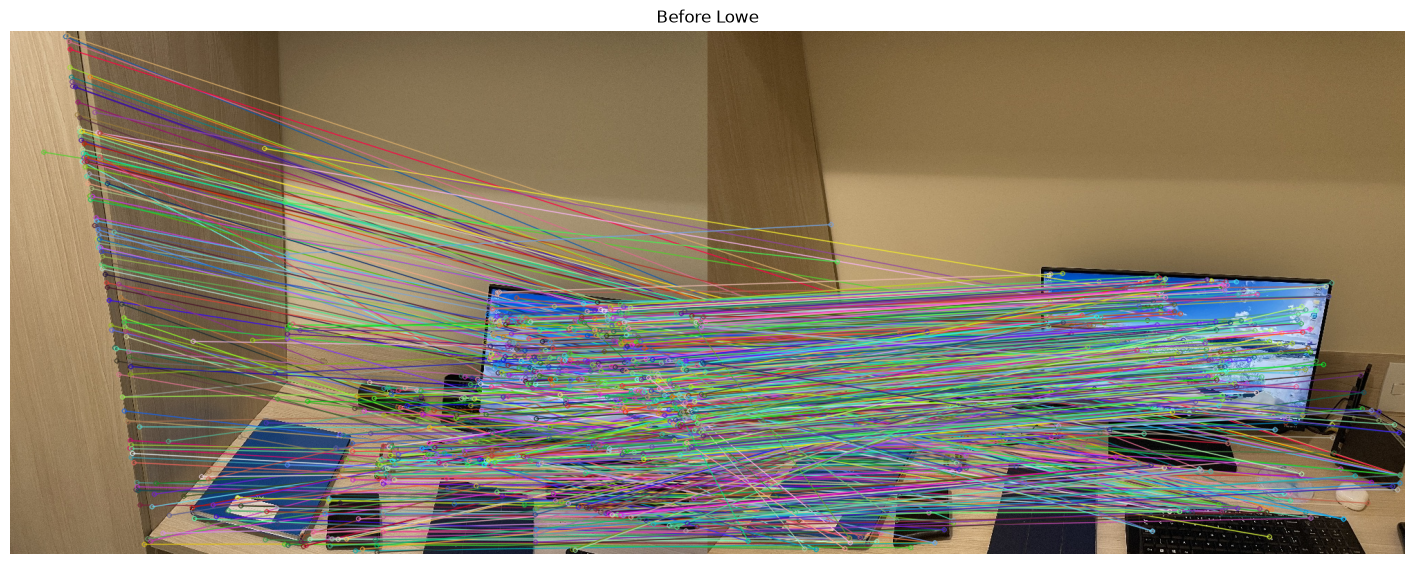

In [11]:
i = 1
j = 2

show_matches(images[i], # imagem sem os keypoints sobrepostos
            images_sift[i]["keypoints"], # keypoints
            images[j], 
            images_sift[j]["keypoints"],
            matches_dict[(i, j)], # matches associados ao par de imagens
            "Before Lowe")

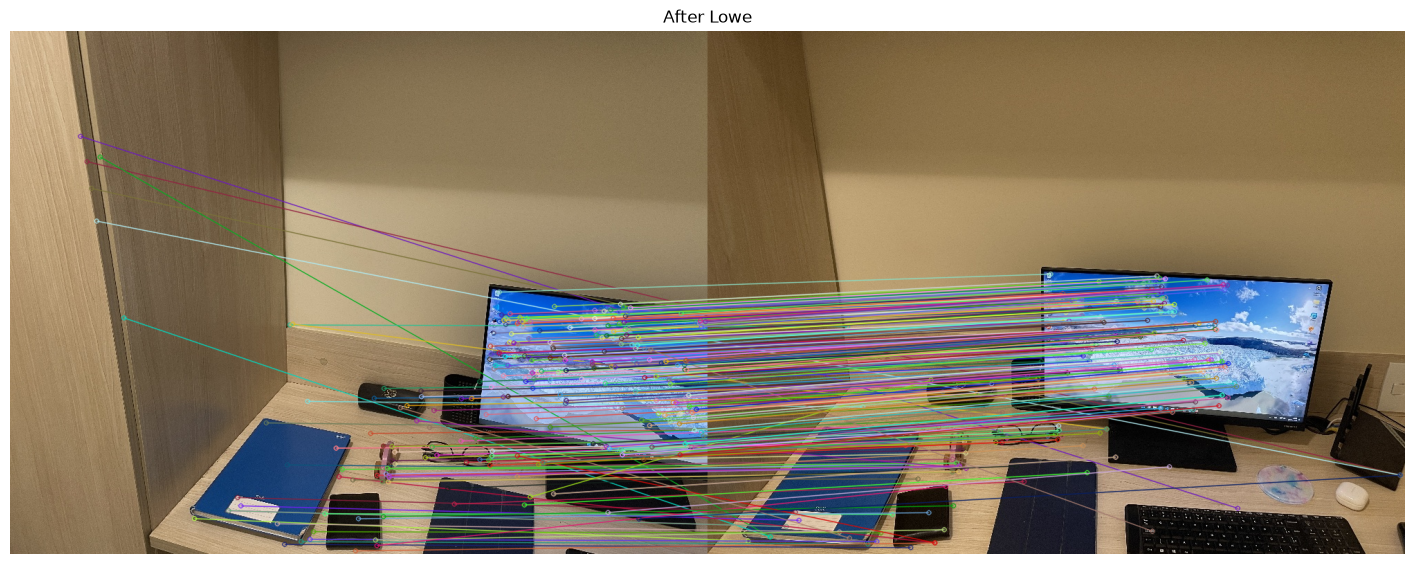

In [12]:
show_matches(images[i], # imagem sem os keypoints sobrepostos
            images_sift[i]["keypoints"], # keypoints
            images[j], 
            images_sift[j]["keypoints"],
            lowe_matches_dict[(i, j)], # matches associados ao par de imagens, filtrados com teste da razão
            "After Lowe")

# Etapa 4

Ordenação automática

In [13]:
from src.ordering import build_connectivity_matrix

connectivity_matrix = build_connectivity_matrix(lowe_matches_dict)

print(connectivity_matrix)

[[  0 150 104  95  88  15  23]
 [150   0 257 204 203  25  17]
 [104 257   0 303 299 102  17]
 [ 95 204 303   0 396 119  43]
 [ 88 203 299 396   0 168  59]
 [ 15  25 102 119 168   0 132]
 [ 23  17  17  43  59 132   0]]


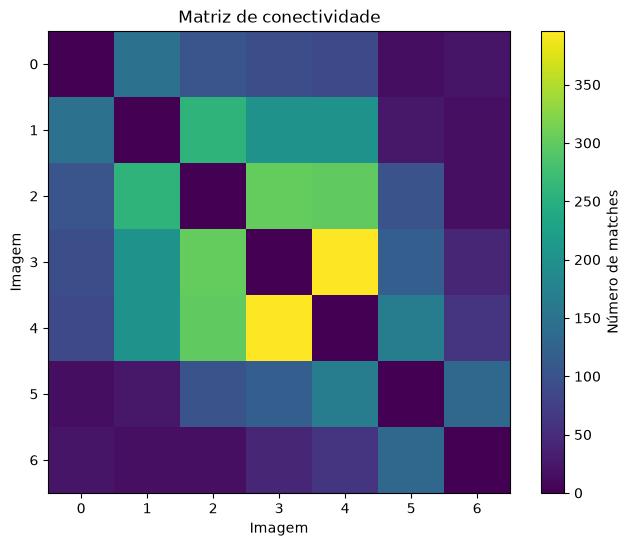

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(
    connectivity_matrix,
    cmap="viridis"
)

plt.colorbar(label="Número de matches")

plt.xlabel("Imagem")
plt.ylabel("Imagem")
plt.title("Matriz de conectividade")

plt.show()

In [15]:
from src.ordering import build_graph

graph = build_graph(
    connectivity_matrix,
    min_matches=20
)

print(graph)

{0: [1, 2, 3, 4, 6], 1: [0, 2, 3, 4, 5], 2: [0, 1, 3, 4, 5], 3: [0, 1, 2, 4, 5, 6], 4: [0, 1, 2, 3, 5, 6], 5: [1, 2, 3, 4, 6], 6: [0, 3, 4, 5]}


# Etapa 5

Homografia e Alinhamento

In [18]:
from src.homography import estimate_homography
from src.composition import (
    compute_global_transforms,
    compose_panorama,
    feather_blend_panorama,
    crop_panorama,
)

homographies = {}
inlier_masks = {}

for i in range(len(images) - 1):

    pair = (i, i + 1)

    pair_matches = lowe_matches_dict[pair]

    print(f"\n===== PAR {i} -> {i+1} =====")
    print("Matches Lowe:", len(pair_matches))

    H, inlier_mask = estimate_homography(
        images_sift[i]["keypoints"],
        images_sift[i + 1]["keypoints"],
        pair_matches
    )

    homographies[pair] = H
    inlier_masks[pair] = inlier_mask

    n_inliers = int(inlier_mask.sum())

    if len(pair_matches) > 0:
        inlier_rate = n_inliers / len(pair_matches)
    else:
        inlier_rate = 0.0

    print("Inliers:", n_inliers)
    print("Inlier rate:", f"{inlier_rate:.2%}")
    print("H:")
    print(H)


===== PAR 0 -> 1 =====
Matches Lowe: 150
Inliers: 130
Inlier rate: 86.67%
H:
[[ 1.19339646e+00 -1.23341493e-02 -2.38555669e+02]
 [ 1.98676924e-02  9.99904550e-01  2.79375210e+01]
 [ 3.04104607e-04 -1.50866977e-04  1.00000000e+00]]

===== PAR 1 -> 2 =====
Matches Lowe: 257
Inliers: 201
Inlier rate: 78.21%
H:
[[ 1.24079237e+00  3.85720776e-02 -3.00418652e+02]
 [ 2.92848776e-02  1.06208599e+00 -2.35915627e+00]
 [ 3.26654149e-04 -1.07294298e-04  1.00000000e+00]]

===== PAR 2 -> 3 =====
Matches Lowe: 303
Inliers: 271
Inlier rate: 89.44%
H:
[[ 1.30925404e+00  7.32546786e-02 -3.06447626e+02]
 [ 4.70659338e-02  1.16752112e+00 -2.57660818e+01]
 [ 3.22319159e-04 -1.96578831e-05  1.00000000e+00]]

===== PAR 3 -> 4 =====
Matches Lowe: 396
Inliers: 361
Inlier rate: 91.16%
H:
[[ 1.40741575e+00  8.78620688e-02 -3.56627069e+02]
 [ 1.00537845e-01  1.28374562e+00 -1.35199074e+02]
 [ 3.74522403e-04  1.18634065e-04  1.00000000e+00]]

===== PAR 4 -> 5 =====
Matches Lowe: 168
Inliers: 96
Inlier rate: 57.14

In [19]:
reference = len(images) // 2

print("Imagem de referência:", reference)

Imagem de referência: 3


In [20]:
global_transforms = compute_global_transforms(
    homographies,
    len(images),
    reference
)

In [21]:
for i, H in enumerate(global_transforms):

    print(f"\nImagem {i} -> referência")

    print(H)


Imagem 0 -> referência
[[ 1.61213159e+00  2.47937906e-01 -1.05961013e+03]
 [ 1.12205966e-01  1.24986678e+00 -2.79692190e+01]
 [ 1.13878988e-03 -2.60949225e-04  7.26788484e-01]]

Imagem 1 -> referência
[[ 1.52655529e+00  1.61183499e-01 -6.99944779e+02]
 [ 8.41731668e-02  1.24458781e+00 -4.26599309e+01]
 [ 7.26009623e-04 -1.15740140e-04  9.03215689e-01]]

Imagem 2 -> referência
[[ 1.30925404e+00  7.32546786e-02 -3.06447626e+02]
 [ 4.70659338e-02  1.16752112e+00 -2.57660818e+01]
 [ 3.22319159e-04 -1.96578831e-05  1.00000000e+00]]

Imagem 3 -> referência
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Imagem 4 -> referência
[[ 6.55376288e-01 -6.56342896e-02  2.24851230e+02]
 [-7.62242713e-02  7.76991775e-01  7.78649297e+01]
 [-2.36410307e-04 -6.75961808e-05  9.06550744e-01]]

Imagem 5 -> referência
[[ 2.19032752e-01 -8.91381362e-02  4.05179568e+02]
 [-6.51564541e-02  5.55000243e-01  3.55291987e+01]
 [-3.55246528e-04  4.08130774e-05  6.11858453e-01]]

Imagem 6 -> referência
[[ 7.73324584e-02 -8.0383

In [22]:
def normalize_H(H):
    H = H.astype(np.float64)

    if abs(H[2, 2]) > 1e-12:
        H = H / H[2, 2]

    return H


for i in range(len(images) - 1):

    H_local = normalize_H(
        homographies[(i, i + 1)]
    )

    G_i = normalize_H(
        global_transforms[i]
    )

    G_next = normalize_H(
        global_transforms[i + 1]
    )

    # Se:
    # G_i = G_next @ H_local
    #
    # então:
    # H_local = inv(G_next) @ G_i

    H_recovered = normalize_H(
        np.linalg.inv(G_next) @ G_i
    )

    error = np.linalg.norm(
        H_local - H_recovered
    )

    print(
        f"Par {i}->{i+1}: "
        f"erro de consistência = {error:.6f}"
    )

Par 0->1: erro de consistência = 0.000000
Par 1->2: erro de consistência = 0.000000
Par 2->3: erro de consistência = 0.000000
Par 3->4: erro de consistência = 0.000000
Par 4->5: erro de consistência = 0.000000
Par 5->6: erro de consistência = 0.000000


In [23]:
def transformed_corners(image, H):

    h, w = image.shape[:2]

    corners = np.array([
        [0, 0],
        [w, 0],
        [w, h],
        [0, h]
    ], dtype=np.float32).reshape(-1, 1, 2)

    transformed = cv2.perspectiveTransform(
        corners,
        H
    )

    return transformed.reshape(-1, 2)

In [24]:
for i, (image, H) in enumerate(
    zip(images, global_transforms)
):

    corners = transformed_corners(
        image,
        H
    )

    print(f"\nImagem {i}")
    print(corners)


Imagem 0
[[-1457.9347    -38.4833 ]
 [  301.60663    45.41255]
 [  448.82236   614.0616 ]
 [-1647.1221   1731.6549 ]]

Imagem 1
[[-774.9476    -47.231167]
 [ 513.03107    25.801687]
 [ 620.7797    635.26556 ]
 [-708.69025  1101.1777  ]]

Imagem 2
[[-306.44763   -25.76608 ]
 [ 764.799      16.360794]
 [ 815.7491    690.3032  ]
 [-254.85457   869.8064  ]]

Imagem 3
[[   0.    0.]
 [1008.    0.]
 [1008.  756.]
 [   0.  756.]]

Imagem 4
[[ 248.02939     85.89142  ]
 [1325.0604       1.5426346]
 [1354.3804     953.4798   ]
 [ 204.84203    777.6869   ]]

Imagem 5
[[ 662.2113     58.067677]
 [2466.6616   -118.802505]
 [1962.5011   1368.229   ]
 [ 525.5706    708.10657 ]]

Imagem 6
[[ 821.7703       5.9942803]
 [4322.7783    -531.39     ]
 [2831.9092    1936.8699   ]
 [ 654.14935    659.44885  ]]


In [25]:
from src.composition import get_panorama_size

width, height, translation = get_panorama_size(
    images,
    global_transforms
)

print("Canvas:")
print("width :", width)
print("height:", height)
print(
    "pixels:",
    width * height
)

Canvas:
width : 5971
height: 2469
pixels: 14742399


In [26]:
panorama, panorama_mask = compose_panorama(
    images,
    global_transforms
)

Canvas do panorama: 5971 x 2469
Processando imagem 1/7...
Processando imagem 2/7...
Processando imagem 3/7...
Processando imagem 4/7...
Processando imagem 5/7...
Processando imagem 6/7...
Processando imagem 7/7...


In [28]:
panorama_crop = crop_panorama(
    panorama,
    panorama_mask
)

print("Panorama crop:", panorama_crop.shape)

Panorama crop: (2464, 5963, 3)


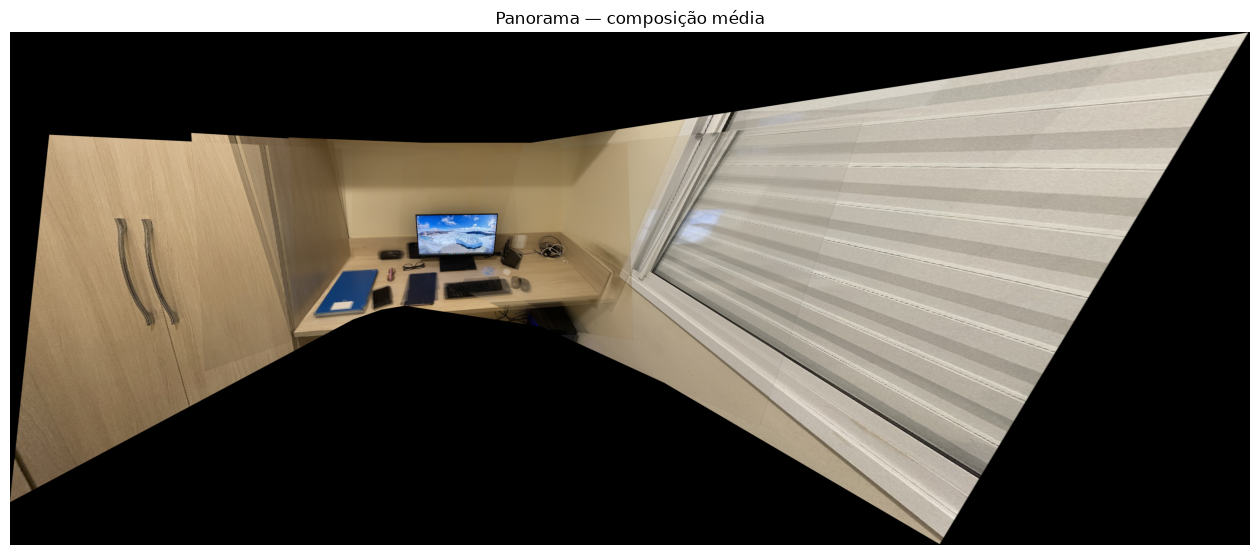

In [29]:
plt.figure(figsize=(16, 8))

plt.imshow(
    cv2.cvtColor(
        panorama,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.title("Panorama — composição média")
plt.show()

plt.close()

# Etapa 6

Composição, Blending e Deghosting

In [ ]:
panorama_naive = compose_average(
    warped_images,
    warped_masks
)

In [ ]:
plt.figure(figsize=(20, 8))

plt.imshow(
    cv2.cvtColor(
        panorama_naive,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Panorama - composição ingênua")
plt.axis("off")
plt.show()

In [ ]:
panorama_deghosted = compose_median(
    warped_images,
    warped_masks
)

In [ ]:
plt.figure(figsize=(20, 8))

plt.imshow(
    cv2.cvtColor(
        panorama_deghosted,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Panorama - deghosting")
plt.axis("off")
plt.show()